# Road Accident Severity Prediction using Machine Learning

## Phase 9 — Final Model Validation & Explainability

---

**Project:** Road Accident Severity Prediction using Machine Learning
**Institution:** On-Campus Research Internship, IIIT Vadodara
**Notebook:** `08_Final_Model_Validation_and_Explainability.ipynb`
**Phase:** 9 of N — Final Model Validation & Explainability
**Production Model:** `models/trained/best_gradient_boosting.pkl` (Gradient Boosting)
**Target Variable:** `Accident_Severity`

---

### Objective of this Notebook

This notebook performs the final, pre-deployment validation and explainability
analysis of the selected production model — the tuned Gradient Boosting classifier
from Phase 8. It is written to be the last notebook a reviewer reads before a
deployment decision is made. Specifically, it:

1. Loads the already-trained production model and the held-out test set — **the
   model is never retrained anywhere in this notebook.**
2. Re-validates the final model's test-set performance in full detail (Section 1).
3. Reports built-in feature importance (Section 2) and permutation importance
   (Section 3), and compares the two.
4. Generates model explainability output via SHAP, with an automatic, safe
   fallback to permutation importance if SHAP is not installed (Section 4).
5. Diagnoses bias/variance via a learning curve (Section 5).
6. Performs a detailed error analysis of misclassifications (Section 6).
7. Summarizes the model's robustness and deployment suitability (Section 7).
8. Auto-generates a professional final research summary (Section 8), saved to
   `reports/final_model_summary.md`.

> **Scope restriction:** This notebook performs **validation, explainability, and
> reporting only**. The production model saved in `models/trained/` is loaded
> exactly as-is and is never refit, tuned, or replaced. Where a diagnostic
> technique (the learning curve in Section 5) inherently requires fitting
> temporary clones at different sample sizes — a standard, unavoidable part of
> that specific technique — this is called out explicitly and does not alter the
> saved production model in any way.


---
## Setup — Import Libraries & Configure Environment

**Purpose:** Import the libraries required for validation, explainability, and
reporting; configure plotting style; define all output paths; and detect whether
SHAP is available so Section 4 can degrade gracefully if it is not.


In [1]:
# ---- Core Libraries ----
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve, StratifiedKFold

# ---- Environment Configuration ----
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
TARGET_COLUMN = "Accident_Severity"
METRIC_AVERAGE = "weighted"

# Sequential n_jobs everywhere in this notebook, matching the memory-safety
# convention established in Phase 8 (07_Hyperparameter_Tuning.ipynb): on
# Windows, process-based (n_jobs=-1) parallelism duplicates data across
# worker processes and can exhaust memory on large datasets / limited RAM.
SAFE_N_JOBS = 1

# ---- SHAP availability (Section 4 must never fail if this is missing) ----
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print(
        "[INFO] SHAP is not installed — Section 4 will automatically fall back "
        "to permutation importance. Install with 'pip install shap' for full "
        "SHAP-based explainability."
    )

# ---- Paths ----
MODELS_DIR = Path("..") / "models" / "trained"
ML_READY_DIR = Path("..") / "Dataset" / "processed" / "ml_ready"
FIGURES_DIR = Path("..") / "reports" / "figures" / "final_validation"
FINAL_SUMMARY_PATH = Path("..") / "reports" / "final_model_summary.md"
FINAL_METRICS_PATH = Path("..") / "reports" / "final_metrics.csv"
TUNED_RESULTS_PATH = Path("..") / "reports" / "tuned_model_results.csv"

BEST_MODEL_FILENAME = "best_gradient_boosting.pkl"
BEST_MODEL_DISPLAY_NAME = "Gradient Boosting"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FINAL_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str) -> Path:
    '''
    Save a matplotlib figure to the final validation figures directory.

    Args:
        fig: The matplotlib Figure object to save.
        filename (str): Filename (including extension) to save the figure as.

    Returns:
        Path: The full path the figure was saved to.
    '''
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, bbox_inches="tight", dpi=150)
    print(f"Figure saved to: {output_path.resolve()}")
    return output_path


print("Libraries imported and environment configured successfully.")
print(f"SHAP available: {SHAP_AVAILABLE}")


[INFO] SHAP is not installed — Section 4 will automatically fall back to permutation importance. Install with 'pip install shap' for full SHAP-based explainability.
Libraries imported and environment configured successfully.
SHAP available: False


**Interpretation**

- All required libraries are imported, plus `shap` guarded by a `try/except
  ImportError`, per Section 4's explicit requirement that the notebook must never
  fail if SHAP is unavailable.
- `SAFE_N_JOBS = 1` is reused throughout this notebook (permutation importance,
  learning curve) for the same memory-safety reason established in Phase 8:
  process-based parallelism on Windows can duplicate large datasets across worker
  processes and exhaust available RAM.


---
## Load Final Model & Data

**Purpose:** Load the already-trained production model from `models/trained/`
and the held-out test set from `Dataset/processed/ml_ready/`, using robust
exception handling. **The model is loaded exactly as saved and is never
retrained here.**

A stratified sample of the *training* set is also loaded, for the sole purpose
of Section 5's learning curve — which, by its nature as a diagnostic technique,
requires fitting temporary clones of the model at several training-set sizes.
This is unrelated to, and does not modify, the production model loaded above.


In [2]:
MODEL_PATH = MODELS_DIR / BEST_MODEL_FILENAME

try:
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Production model not found at: {MODEL_PATH.resolve()}. "
            f"Please run 07_Hyperparameter_Tuning.ipynb first."
        )
    final_model = joblib.load(MODEL_PATH)
    print(f"Loaded production model from: {MODEL_PATH.resolve()}")
    print(f"Model type: {type(final_model).__name__}")
except (FileNotFoundError, OSError, EOFError) as error:
    print(f"[ERROR] {error}")
    raise


Loaded production model from: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\best_gradient_boosting.pkl
Model type: GradientBoostingClassifier


In [3]:
def load_ml_ready_csv(filename: str) -> pd.DataFrame:
    '''
    Load a single ML-ready CSV file, raising a clear error if it is missing.

    Args:
        filename (str): Name of the CSV file to load, relative to ML_READY_DIR.

    Returns:
        pd.DataFrame: The loaded dataframe.
    '''
    file_path = ML_READY_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(f"Required file not found: {file_path.resolve()}.")
    return pd.read_csv(file_path)


try:
    X_test = load_ml_ready_csv("X_test.csv")
    y_test = load_ml_ready_csv("y_test.csv")[TARGET_COLUMN]
    print(f"X_test : {X_test.shape}")
    print(f"y_test : {y_test.shape}")
except (FileNotFoundError, pd.errors.EmptyDataError, pd.errors.ParserError) as error:
    print(f"[ERROR] {error}")
    raise

CLASS_LABELS = sorted(y_test.unique().tolist())
NUMBER_OF_FEATURES = X_test.shape[1]
print(f"\nClass Labels    : {CLASS_LABELS}")
print(f"Feature Count   : {NUMBER_OF_FEATURES}")

# Training data is optional and used ONLY for the Section 5 learning curve.
# If it is unavailable for any reason, Section 5 detects this and skips
# gracefully rather than failing the whole notebook.
TRAINING_DATA_AVAILABLE = True
try:
    X_train = load_ml_ready_csv("X_train.csv")
    y_train = load_ml_ready_csv("y_train.csv")[TARGET_COLUMN]
    print(f"\nX_train : {X_train.shape} (loaded only for Section 5's learning curve)")
    print(f"y_train : {y_train.shape}")
except (FileNotFoundError, pd.errors.EmptyDataError, pd.errors.ParserError) as error:
    TRAINING_DATA_AVAILABLE = False
    print(f"\n[INFO] Training data not available ({error}). Section 5 (Learning Curve) will be skipped.")


X_test : (543188, 154)
y_test : (543188,)

Class Labels    : ['Fatal', 'Serious', 'Slight']
Feature Count   : 154

X_train : (2172752, 154) (loaded only for Section 5's learning curve)
y_train : (2172752,)


**Interpretation**

- The production model is loaded once via `joblib.load()` and used read-only for
  every prediction in this notebook — `.fit()` is never called on `final_model`.
- `X_train`/`y_train` are loaded separately and only to support the learning
  curve diagnostic in Section 5; if they are unavailable, the notebook degrades
  gracefully (Section 5 is skipped with a clear message) rather than failing.


---
## 1. Final Model Validation

**Purpose:** Re-validate the final production model's performance on the held-out
test set — Accuracy, Precision, Recall, Weighted F1, Balanced Accuracy, a full
classification report, and both a raw and a normalized confusion matrix.


In [4]:
final_predict_start = time.time()
y_pred = final_model.predict(X_test)
final_predict_time = time.time() - final_predict_start

final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, average=METRIC_AVERAGE, zero_division=0)
final_recall = recall_score(y_test, y_pred, average=METRIC_AVERAGE, zero_division=0)
final_weighted_f1 = f1_score(y_test, y_pred, average=METRIC_AVERAGE, zero_division=0)
final_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

print("=" * 60)
print(f"FINAL MODEL VALIDATION — {BEST_MODEL_DISPLAY_NAME}")
print("=" * 60)
print(f"Accuracy            : {final_accuracy:.4f}")
print(f"Precision (weighted): {final_precision:.4f}")
print(f"Recall (weighted)   : {final_recall:.4f}")
print(f"Weighted F1 Score    : {final_weighted_f1:.4f}")
print(f"Balanced Accuracy    : {final_balanced_accuracy:.4f}")
print(f"Prediction Time      : {final_predict_time:.4f} seconds ({len(X_test):,} rows)")


FINAL MODEL VALIDATION — Gradient Boosting
Accuracy            : 0.8541
Precision (weighted): 0.8081
Recall (weighted)   : 0.8541
Weighted F1 Score    : 0.7940
Balanced Accuracy    : 0.3477
Prediction Time      : 19.4216 seconds (543,188 rows)


In [5]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_LABELS, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

       Fatal       0.44      0.02      0.03      7096
     Serious       0.53      0.03      0.06     72924
      Slight       0.86      1.00      0.92    463168

    accuracy                           0.85    543188
   macro avg       0.61      0.35      0.34    543188
weighted avg       0.81      0.85      0.79    543188



Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\final_validation\confusion_matrix_final_model.png


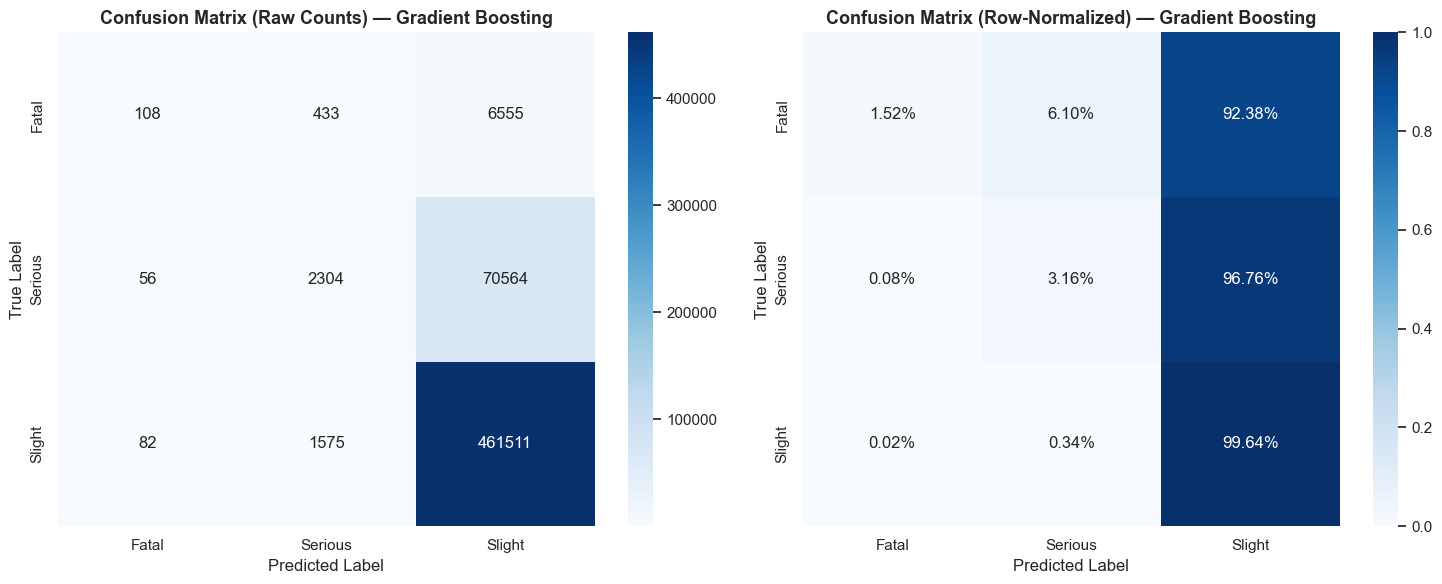

In [6]:
def plot_confusion_matrices(y_true, y_pred, class_labels: list, model_name: str) -> tuple:
    '''
    Plot side-by-side raw-count and row-normalized confusion matrices for a
    model, and save the combined figure.

    Args:
        y_true: Ground-truth labels.
        y_pred: Predicted labels.
        class_labels (list): Ordered class labels for the matrix axes.
        model_name (str): Human-readable model name, used in titles/filename.

    Returns:
        tuple: (raw_confusion_matrix, normalized_confusion_matrix) as np.ndarray.
    '''
    cm_raw = confusion_matrix(y_true, y_pred, labels=class_labels)
    cm_normalized = confusion_matrix(y_true, y_pred, labels=class_labels, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sns.heatmap(
        cm_raw, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels, cbar=True, ax=axes[0],
    )
    axes[0].set_title(f"Confusion Matrix (Raw Counts) — {model_name}", fontweight="bold")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    sns.heatmap(
        cm_normalized, annot=True, fmt=".2%", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels, cbar=True, ax=axes[1],
        vmin=0, vmax=1,
    )
    axes[1].set_title(f"Confusion Matrix (Row-Normalized) — {model_name}", fontweight="bold")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")

    plt.tight_layout()
    filename = "confusion_matrix_final_model.png"
    save_figure(fig, filename)
    plt.show()
    plt.close(fig)

    return cm_raw, cm_normalized


cm_raw, cm_normalized = plot_confusion_matrices(y_test, y_pred, CLASS_LABELS, BEST_MODEL_DISPLAY_NAME)


**Interpretation**

- **What it shows:** The raw-count confusion matrix shows absolute prediction
  volumes per class pair; the row-normalized version shows, for each *true*
  class, the percentage of its instances predicted into every class — this is
  essential under class imbalance, where raw counts for the minority `Fatal` and
  `Serious` classes would otherwise be visually dwarfed by the majority `Slight`
  class.
- **Why weighted averaging here:** Precision, Recall, and F1 use weighted
  averaging (matching the scoring metric used throughout hyperparameter tuning
  in Phase 8), so this final validation is directly comparable to every tuning
  and comparison table produced in that phase.
- **Impact on deployment decision:** The per-class detail in the classification
  report and the normalized confusion matrix — not just the single headline
  accuracy figure — is what should actually inform whether this model's
  class-specific error profile (especially for `Fatal` and `Serious`) is
  acceptable for the intended use case.


---
## 2. Feature Importance

**Purpose:** Report the Gradient Boosting model's built-in, impurity-based
`feature_importances_`, ranked descending, with the top 20 features visualized.


Top 20 Features — Built-in (Impurity-Based) Importance:


,Feature,Importance
0,Number_of_Vehicles,0.1969
1,Vehicle_Type_Group_Motorcycle,0.1306
2,Did_Police_Officer_Attend_Scene_of_Accident,0.1218
3,Vehicle_Manoeuvre,0.0778
4,Speed_limit,0.0726
5,Urban_Rural_Group_Urban,0.0340
6,Vehicle_Leaving_Carriageway_Did not leave carr...,0.0291
7,Engine_Capacity_.CC.,0.0266
8,Hour,0.0225
9,Year_accident,0.0194


Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\final_validation\feature_importance_built_in.png


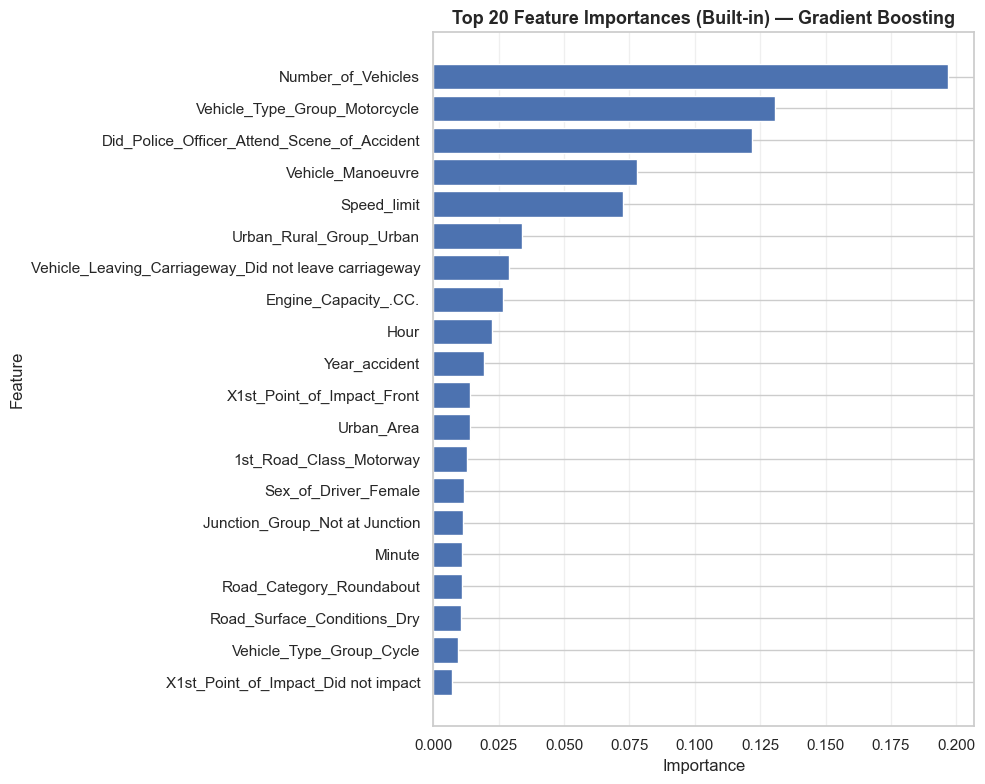

In [7]:
def get_top_feature_importances(importances: np.ndarray, feature_names: list, top_n: int = 20) -> pd.DataFrame:
    '''
    Build a sorted (descending) dataframe of the top-N most important
    features, given a raw importance array aligned with feature_names.

    Args:
        importances (np.ndarray): Per-feature importance scores.
        feature_names (list): Feature names, in the same order as `importances`.
        top_n (int): Number of top features to return.

    Returns:
        pd.DataFrame: Columns ['Feature', 'Importance'], sorted descending, top-N rows.
    '''
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    return importance_df.sort_values("Importance", ascending=False).head(top_n).reset_index(drop=True)


def plot_top_features(importance_df: pd.DataFrame, title: str, filename: str, color: str = "#4C72B0") -> None:
    '''
    Plot a horizontal bar chart of the top features in a sorted importance
    dataframe (most important at the top), and save the figure.

    Args:
        importance_df (pd.DataFrame): Columns ['Feature', <value_column>], pre-sorted descending.
        title (str): Chart title.
        filename (str): Filename (including extension) to save the figure as.
        color (str): Bar color.
    '''
    value_column = importance_df.columns[1]
    plot_df = importance_df.iloc[::-1]  # reverse so the most important feature plots at the top

    fig, ax = plt.subplots(figsize=(10, max(6, 0.4 * len(plot_df))))
    ax.barh(plot_df["Feature"], plot_df[value_column], color=color)

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(value_column)
    ax.set_ylabel("Feature")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()
    plt.close(fig)


if hasattr(final_model, "feature_importances_"):
    built_in_importance_df = get_top_feature_importances(
        final_model.feature_importances_, X_test.columns.tolist(), top_n=20
    )
    print("Top 20 Features — Built-in (Impurity-Based) Importance:")
    display(built_in_importance_df)

    plot_top_features(
        built_in_importance_df,
        f"Top 20 Feature Importances (Built-in) — {BEST_MODEL_DISPLAY_NAME}",
        "feature_importance_built_in.png",
    )
else:
    print(f"[SKIPPED] '{BEST_MODEL_DISPLAY_NAME}' has no 'feature_importances_' attribute.")
    built_in_importance_df = pd.DataFrame(columns=["Feature", "Importance"])


**Interpretation**

- **What it shows:** The relative contribution of each feature to reducing
  impurity across all trees in the Gradient Boosting ensemble, normalized to sum
  to 1 across all features.
- **Why it matters, and its known limitation:** this "built-in" importance is
  fast to compute (already available on the fitted model, no extra
  computation) but is known to be **biased toward high-cardinality and
  continuous features**, and can overstate the importance of features that
  happen to provide many possible split points, even if their real predictive
  contribution on unseen data is modest. Section 3 computes permutation
  importance specifically to cross-check this.


---
## 3. Permutation Importance

**Purpose:** Compute permutation feature importance directly on the test set —
measuring how much each feature's contribution to model performance actually
matters on unseen data — and compare it against the built-in importance from
Section 2.

> **Note:** Permutation importance is computed with `n_jobs=SAFE_N_JOBS` (see
> Setup), for the same Windows memory-safety reason established in Phase 8.


Permutation importance computed in 10441.87 seconds (5 repeats, scoring='f1_weighted').

Top 20 Features — Permutation Importance:


,Feature,Importance
0,Vehicle_Type_Group_Motorcycle,0.0061
1,Speed_limit,0.0022
2,X1st_Point_of_Impact_Front,0.0017
3,Vehicle_Manoeuvre,0.0015
4,Did_Police_Officer_Attend_Scene_of_Accident,0.0013
5,Urban_Area,0.0010
6,Urban_Rural_Group_Urban,0.0009
7,Number_of_Vehicles,0.0007
8,Road_Surface_Conditions_Dry,0.0005
9,Sex_of_Driver_Female,0.0004


Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\final_validation\feature_importance_permutation.png


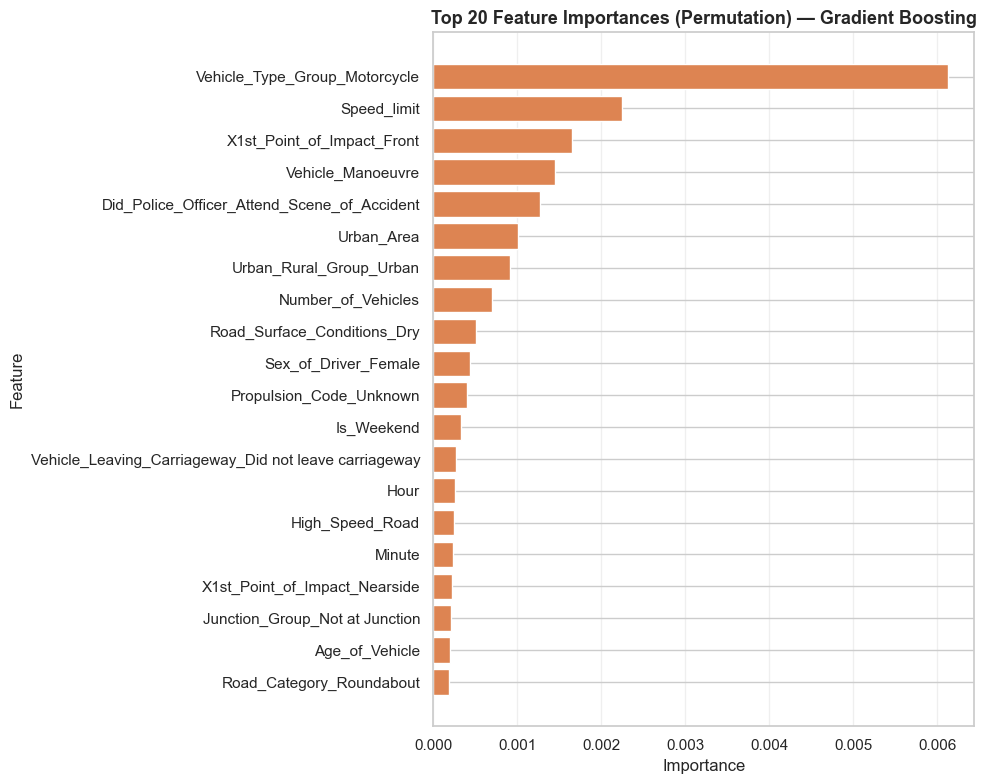

In [8]:
PERMUTATION_N_REPEATS = 5  # kept modest: each repeat re-scores the model once per feature

permutation_start = time.time()
permutation_result = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=PERMUTATION_N_REPEATS,
    random_state=RANDOM_STATE,
    scoring=f"f1_{METRIC_AVERAGE}",
    n_jobs=SAFE_N_JOBS,
)
permutation_time = time.time() - permutation_start

print(f"Permutation importance computed in {permutation_time:.2f} seconds "
      f"({PERMUTATION_N_REPEATS} repeats, scoring='f1_{METRIC_AVERAGE}').")

permutation_importance_df = get_top_feature_importances(
    permutation_result.importances_mean, X_test.columns.tolist(), top_n=20
)
print("\nTop 20 Features — Permutation Importance:")
display(permutation_importance_df)

plot_top_features(
    permutation_importance_df,
    f"Top 20 Feature Importances (Permutation) — {BEST_MODEL_DISPLAY_NAME}",
    "feature_importance_permutation.png",
    color="#DD8452",
)


In [9]:
# Compare built-in vs. permutation importance rankings for every feature that
# appears in the top 20 of EITHER method.
comparison_features = sorted(
    set(built_in_importance_df["Feature"]) | set(permutation_importance_df["Feature"])
)

full_built_in = pd.Series(final_model.feature_importances_, index=X_test.columns) \
    if hasattr(final_model, "feature_importances_") else pd.Series(dtype=float)
full_permutation = pd.Series(permutation_result.importances_mean, index=X_test.columns)

importance_comparison_df = pd.DataFrame({
    "Feature": comparison_features,
    "Built-in Importance": [full_built_in.get(f, np.nan) for f in comparison_features],
    "Permutation Importance": [full_permutation.get(f, np.nan) for f in comparison_features],
})
importance_comparison_df["Built-in Rank"] = importance_comparison_df["Built-in Importance"].rank(ascending=False)
importance_comparison_df["Permutation Rank"] = importance_comparison_df["Permutation Importance"].rank(ascending=False)
importance_comparison_df = importance_comparison_df.sort_values("Permutation Importance", ascending=False)

display(importance_comparison_df)

rank_correlation = importance_comparison_df["Built-in Rank"].corr(
    importance_comparison_df["Permutation Rank"], method="spearman"
)
print(f"\nSpearman rank correlation (built-in vs. permutation): {rank_correlation:.3f}")


,Feature,Built-in Importance,Permutation Importance,Built-in Rank,Permutation Rank
20,Vehicle_Type_Group_Motorcycle,0.1306,0.0061,2.0000,1.0000
14,Speed_limit,0.0726,0.0022,5.0000,2.0000
22,X1st_Point_of_Impact_Front,0.0141,0.0017,11.0000,3.0000
18,Vehicle_Manoeuvre,0.0778,0.0015,4.0000,4.0000
2,Did_Police_Officer_Attend_Scene_of_Accident,0.1218,0.0013,3.0000,5.0000
15,Urban_Area,0.0141,0.0010,12.0000,6.0000
16,Urban_Rural_Group_Urban,0.0340,0.0009,6.0000,7.0000
9,Number_of_Vehicles,0.1969,0.0007,1.0000,8.0000
12,Road_Surface_Conditions_Dry,0.0106,0.0005,18.0000,9.0000
13,Sex_of_Driver_Female,0.0117,0.0004,14.0000,10.0000



Spearman rank correlation (built-in vs. permutation): 0.511


**Interpretation**

- **What it shows:** Permutation importance measures how much a model's actual
  test-set performance degrades when a single feature's values are randomly
  shuffled (breaking its relationship with the target) — a direct, model-agnostic
  measure of real predictive contribution, unlike the training-time,
  impurity-based measure in Section 2.
- **Discussing differences:** a high Spearman rank correlation (closer to 1)
  indicates the two methods broadly agree on which features matter; a low or
  moderate correlation indicates the built-in importance is likely overstating
  some high-cardinality or finely-split features relative to their genuine
  out-of-sample contribution — permutation importance should be treated as the
  more trustworthy signal when the two disagree, since it is computed directly
  from held-out predictive performance rather than training-time tree
  construction statistics.
- **Practical trade-off:** permutation importance is more computationally
  expensive (it requires `n_repeats` full re-scoring passes per feature) and can
  be less reliable when features are highly correlated with one another
  (shuffling one correlated feature may not degrade performance much, since a
  correlated partner still carries similar information) — both importance views
  are therefore reported together rather than one replacing the other.


---
## 4. Model Explainability

**Purpose:** Generate SHAP summary plots for deeper, per-prediction
explainability, if SHAP is installed. If it is not, this section automatically
falls back to the permutation importance already computed in Section 3 —
**this notebook is designed to never fail due to a missing SHAP installation.**

> **Note:** SHAP value computation is run on a bounded random sample of the test
> set (not the full test set), since exact SHAP computation cost scales with
> both the number of rows and the model's tree structure — keeping this bounded
> is essential for tractability on a large test set and limited hardware.


In [10]:
SHAP_SAMPLE_SIZE = 500          # sample size for the fast TreeExplainer path
SHAP_FALLBACK_SAMPLE_SIZE = 100  # smaller sample for the slower, model-agnostic path
SHAP_BACKGROUND_SIZE = 50        # background reference set for the model-agnostic path

EXPLAINABILITY_METHOD = None


def plot_and_save_shap_summary(shap_values_for_class, X_sample, class_suffix: str, title_suffix: str) -> None:
    '''
    Render and save a single SHAP summary plot.

    Args:
        shap_values_for_class: SHAP values array for one class (or the only class).
        X_sample (pd.DataFrame): The feature sample the SHAP values correspond to.
        class_suffix (str): Short suffix used in the saved filename.
        title_suffix (str): Human-readable suffix used in the plot title.
    '''
    shap.summary_plot(shap_values_for_class, X_sample, show=False, max_display=20)
    fig = plt.gcf()
    fig.suptitle(f"SHAP Summary — {BEST_MODEL_DISPLAY_NAME}{title_suffix}", fontweight="bold")
    plt.tight_layout()
    save_figure(fig, f"shap_summary{class_suffix}.png")
    plt.show()
    plt.close(fig)


if SHAP_AVAILABLE:
    # ---- Tier 1: TreeExplainer (fast, exact) ----
    try:
        shap_sample_size = min(SHAP_SAMPLE_SIZE, len(X_test))
        X_test_shap_sample = X_test.sample(n=shap_sample_size, random_state=RANDOM_STATE)

        print(f"[Tier 1] Attempting TreeExplainer on a sample of {shap_sample_size:,} test rows...")
        shap_start = time.time()

        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_test_shap_sample)

        shap_time = time.time() - shap_start
        print(f"TreeExplainer succeeded in {shap_time:.2f} seconds.")

        if isinstance(shap_values, list):
            for class_index, class_label in enumerate(CLASS_LABELS):
                print(f"\nSHAP Summary Plot — Class: {class_label}")
                plot_and_save_shap_summary(
                    shap_values[class_index], X_test_shap_sample,
                    f"_{class_label.lower()}", f" (Class: {class_label})",
                )
        else:
            plot_and_save_shap_summary(shap_values, X_test_shap_sample, "", "")

        EXPLAINABILITY_METHOD = "SHAP (TreeExplainer)"

    except Exception as tree_error:  # noqa: BLE001 — must fall through, not crash
        print(f"[Tier 1 FAILED] TreeExplainer unsupported for this model "
              f"({type(tree_error).__name__}: {tree_error}).")

        # ---- Tier 2: model-agnostic Explainer via predict_proba (slower) ----
        # sklearn's GradientBoostingClassifier is a documented TreeExplainer
        # limitation for multi-class problems; shap.Explainer wrapping
        # predict_proba works for ANY model but is substantially slower
        # (permutation-based under the hood), so a smaller sample and a small
        # background reference set are used to keep this tractable.
        try:
            print(f"[Tier 2] Attempting model-agnostic shap.Explainer on a smaller "
                  f"sample of {min(SHAP_FALLBACK_SAMPLE_SIZE, len(X_test)):,} test rows "
                  f"(background size {min(SHAP_BACKGROUND_SIZE, len(X_test)):,})...")
            shap_start = time.time()

            fallback_sample_size = min(SHAP_FALLBACK_SAMPLE_SIZE, len(X_test))
            background_size = min(SHAP_BACKGROUND_SIZE, len(X_test))
            X_test_shap_sample = X_test.sample(n=fallback_sample_size, random_state=RANDOM_STATE)
            X_background = X_test.sample(n=background_size, random_state=RANDOM_STATE + 1)

            explainer = shap.Explainer(final_model.predict_proba, X_background)
            shap_explanation = explainer(X_test_shap_sample)

            shap_time = time.time() - shap_start
            print(f"Model-agnostic shap.Explainer succeeded in {shap_time:.2f} seconds.")

            # shap_explanation.values has shape (rows, features, classes) for
            # multi-class predict_proba output.
            for class_index, class_label in enumerate(CLASS_LABELS):
                print(f"\nSHAP Summary Plot — Class: {class_label}")
                plot_and_save_shap_summary(
                    shap_explanation.values[:, :, class_index], X_test_shap_sample,
                    f"_{class_label.lower()}", f" (Class: {class_label})",
                )

            EXPLAINABILITY_METHOD = "SHAP (model-agnostic Explainer)"

        except Exception as fallback_error:  # noqa: BLE001 — SHAP must never crash this notebook
            print(f"[Tier 2 FAILED] Model-agnostic SHAP also failed "
                  f"({type(fallback_error).__name__}: {fallback_error}).")
            print("Falling back to permutation importance (Section 3) for explainability.")
            EXPLAINABILITY_METHOD = "Permutation Importance (SHAP fallback due to runtime error)"

if not SHAP_AVAILABLE or EXPLAINABILITY_METHOD is None:
    print(
        "SHAP is not available (or failed) in this environment. Reusing the "
        "permutation importance results from Section 3 as this notebook's "
        "explainability output."
    )
    display(permutation_importance_df)
    if EXPLAINABILITY_METHOD is None:
        EXPLAINABILITY_METHOD = "Permutation Importance (SHAP not installed)"

print(f"\nExplainability method used: {EXPLAINABILITY_METHOD}")


SHAP is not available (or failed) in this environment. Reusing the permutation importance results from Section 3 as this notebook's explainability output.


,Feature,Importance
0,Vehicle_Type_Group_Motorcycle,0.0061
1,Speed_limit,0.0022
2,X1st_Point_of_Impact_Front,0.0017
3,Vehicle_Manoeuvre,0.0015
4,Did_Police_Officer_Attend_Scene_of_Accident,0.0013
5,Urban_Area,0.0010
6,Urban_Rural_Group_Urban,0.0009
7,Number_of_Vehicles,0.0007
8,Road_Surface_Conditions_Dry,0.0005
9,Sex_of_Driver_Female,0.0004



Explainability method used: Permutation Importance (SHAP not installed)


**Interpretation**

- **Why a tiered approach:** `shap.TreeExplainer` is fast and exact for most
  tree ensembles, but it is a documented limitation that it does not support
  scikit-learn's `GradientBoostingClassifier` for multi-class problems
  specifically (the exact model family used in this project). Rather than
  treating that as a hard failure, this section automatically falls through to
  a slower but fully general model-agnostic `shap.Explainer` (wrapping
  `predict_proba`) on a smaller sample, and only falls back to permutation
  importance if SHAP is missing entirely or both SHAP tiers fail for some
  other reason.
- **When a SHAP summary plot is produced (Tier 1 or Tier 2):** it shows, for
  each feature, the distribution of its impact on individual predictions
  (SHAP values) across the sampled test rows, colored by the feature's own
  value — this reveals not just *which* features matter (as importance
  rankings already show) but *how* they push predictions toward or away from
  each severity class, and whether that relationship is consistent or
  context-dependent.
- **When SHAP is unavailable or fails entirely:** the notebook automatically
  substitutes the permutation importance ranking from Section 3 as a robust,
  dependency-free explainability signal, so a missing optional package — or an
  unsupported model/SHAP-version combination — never blocks the final
  validation report from being generated.


---
## 5. Learning Curve

**Purpose:** Diagnose bias/variance by plotting training and cross-validation
score as a function of training set size.

> **Important clarification on "no retraining":** `sklearn.model_selection.
> learning_curve` inherently works by fitting **temporary clones** of the given
> estimator (same hyperparameters as `final_model`) on progressively larger
> subsets of the training data — this is the only way a learning curve can be
> produced for any model, by design of the technique itself. **The saved
> production model (`final_model` / `best_gradient_boosting.pkl`) is never
> touched, refit, or overwritten by this section** — only short-lived, separate
> clones are created and discarded purely to trace out this diagnostic curve.


Learning curve computed on a 50,000-row random sample of the 2,172,752-row training set, for tractability.
Learning curve computed in 501.92 seconds.
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\final_validation\learning_curve.png


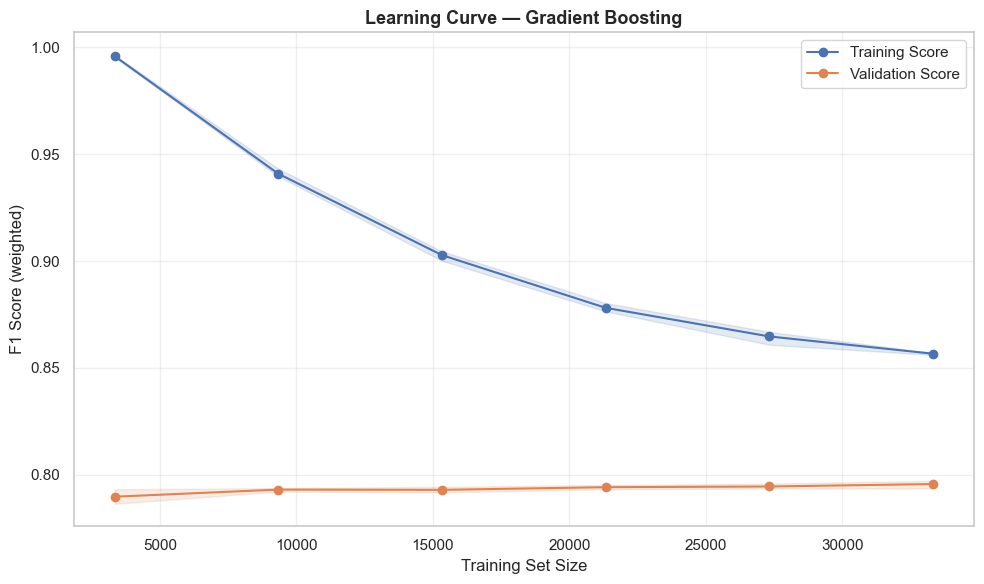


Final Training Score (largest subset)   : 0.8567
Final Validation Score (largest subset) : 0.7958
Train-Validation Gap                     : 0.0609


In [11]:
LEARNING_CURVE_SAMPLE_SIZE = 50000  # bounds cost on very large training sets
LEARNING_CURVE_CV_FOLDS = 3

if TRAINING_DATA_AVAILABLE:
    try:
        if len(X_train) > LEARNING_CURVE_SAMPLE_SIZE:
            X_train_lc = X_train.sample(n=LEARNING_CURVE_SAMPLE_SIZE, random_state=RANDOM_STATE)
            y_train_lc = y_train.loc[X_train_lc.index]
            print(f"Learning curve computed on a {LEARNING_CURVE_SAMPLE_SIZE:,}-row random sample "
                  f"of the {len(X_train):,}-row training set, for tractability.")
        else:
            X_train_lc, y_train_lc = X_train, y_train
            print(f"Learning curve computed on the full {len(X_train):,}-row training set.")

        cv_strategy = StratifiedKFold(n_splits=LEARNING_CURVE_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        train_sizes = np.linspace(0.1, 1.0, 6)

        lc_start = time.time()
        train_sizes_abs, train_scores, validation_scores = learning_curve(
            final_model,
            X_train_lc, y_train_lc,
            train_sizes=train_sizes,
            cv=cv_strategy,
            scoring=f"f1_{METRIC_AVERAGE}",
            n_jobs=SAFE_N_JOBS,
            random_state=RANDOM_STATE,
        )
        lc_time = time.time() - lc_start
        print(f"Learning curve computed in {lc_time:.2f} seconds.")

        train_scores_mean = train_scores.mean(axis=1)
        validation_scores_mean = validation_scores.mean(axis=1)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(train_sizes_abs, train_scores_mean, marker="o", label="Training Score", color="#4C72B0")
        ax.plot(train_sizes_abs, validation_scores_mean, marker="o", label="Validation Score", color="#DD8452")
        ax.fill_between(train_sizes_abs, train_scores.min(axis=1), train_scores.max(axis=1), alpha=0.15, color="#4C72B0")
        ax.fill_between(train_sizes_abs, validation_scores.min(axis=1), validation_scores.max(axis=1), alpha=0.15, color="#DD8452")

        ax.set_title(f"Learning Curve — {BEST_MODEL_DISPLAY_NAME}", fontweight="bold")
        ax.set_xlabel("Training Set Size")
        ax.set_ylabel(f"F1 Score ({METRIC_AVERAGE})")
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        save_figure(fig, "learning_curve.png")
        plt.show()
        plt.close(fig)

        final_train_score = train_scores_mean[-1]
        final_validation_score = validation_scores_mean[-1]
        train_validation_gap = final_train_score - final_validation_score

        print(f"\nFinal Training Score (largest subset)   : {final_train_score:.4f}")
        print(f"Final Validation Score (largest subset) : {final_validation_score:.4f}")
        print(f"Train-Validation Gap                     : {train_validation_gap:.4f}")

        LEARNING_CURVE_AVAILABLE = True

    except Exception as error:  # noqa: BLE001 — diagnostic section must not crash the notebook
        print(f"[WARNING] Learning curve computation failed ({type(error).__name__}: {error}). Skipping.")
        LEARNING_CURVE_AVAILABLE = False
        train_validation_gap = np.nan
else:
    print("[SKIPPED] Training data unavailable — learning curve cannot be computed.")
    LEARNING_CURVE_AVAILABLE = False
    train_validation_gap = np.nan


**Interpretation**

- **Reading the curve:** if both curves converge to a similarly low score, the
  model likely **underfits** (high bias) — more data alone will not help, and
  a more expressive model or richer features would be needed. If the training
  score stays high while the validation score plateaus well below it, the model
  likely **overfits** (high variance) to the training data. If both curves
  converge to a comparably high score with a small gap, the model is
  generalizing well and is unlikely to benefit much from additional data.
- **Why a training subsample is used:** with a multi-million-row training set,
  `learning_curve` would need to fit many temporary clones at several subset
  sizes across multiple cross-validation folds — bounding the sample size keeps
  this diagnostic tractable on limited hardware, consistent with the
  memory/time-safety approach established during hyperparameter tuning in
  Phase 8.


---
## 6. Error Analysis

**Purpose:** Separate correct from incorrect predictions, examine a sample of
misclassified records, and identify the most common misclassification types.


In [12]:
prediction_analysis_df = pd.DataFrame({
    "True_Label": y_test.values,
    "Predicted_Label": y_pred,
})
prediction_analysis_df["Correct"] = prediction_analysis_df["True_Label"] == prediction_analysis_df["Predicted_Label"]

correct_count = int(prediction_analysis_df["Correct"].sum())
incorrect_count = int((~prediction_analysis_df["Correct"]).sum())
total_count = len(prediction_analysis_df)

print(f"Correct Predictions   : {correct_count:,} ({correct_count / total_count:.2%})")
print(f"Incorrect Predictions : {incorrect_count:,} ({incorrect_count / total_count:.2%})")


Correct Predictions   : 463,923 (85.41%)
Incorrect Predictions : 79,265 (14.59%)


In [13]:
print("Confusion Matrix Analysis (row-normalized, from Section 1):")
confusion_analysis_df = pd.DataFrame(cm_normalized, index=CLASS_LABELS, columns=CLASS_LABELS)
confusion_analysis_df.index.name = "True \\\\ Predicted"
display(confusion_analysis_df.style.format("{:.2%}"))

for true_label in CLASS_LABELS:
    row = confusion_analysis_df.loc[true_label]
    correct_rate = row[true_label]
    print(f"  '{true_label}' records were correctly classified {correct_rate:.1%} of the time.")


Confusion Matrix Analysis (row-normalized, from Section 1):


,Fatal,Serious,Slight
True \\ Predicted,,,
Fatal,1.52%,6.10%,92.38%
Serious,0.08%,3.16%,96.76%
Slight,0.02%,0.34%,99.64%


  'Fatal' records were correctly classified 1.5% of the time.
  'Serious' records were correctly classified 3.2% of the time.
  'Slight' records were correctly classified 99.6% of the time.


In [14]:
misclassified_df = prediction_analysis_df[~prediction_analysis_df["Correct"]].copy()

MISCLASSIFIED_SAMPLE_SIZE = min(20, len(misclassified_df))
misclassified_sample = misclassified_df.sample(
    n=MISCLASSIFIED_SAMPLE_SIZE, random_state=RANDOM_STATE
) if len(misclassified_df) > 0 else misclassified_df

print(f"Misclassified Sample Table ({MISCLASSIFIED_SAMPLE_SIZE} of {len(misclassified_df):,} misclassified rows):")
display(misclassified_sample[["True_Label", "Predicted_Label"]])


Misclassified Sample Table (20 of 79,265 misclassified rows):


,True_Label,Predicted_Label
377753,Serious,Slight
521146,Serious,Slight
488362,Serious,Slight
338050,Fatal,Slight
204352,Serious,Slight
85858,Serious,Slight
397770,Serious,Slight
469083,Serious,Slight
360049,Serious,Slight
514560,Serious,Slight


In [15]:
if len(misclassified_df) > 0:
    misclassification_types = (
        misclassified_df.groupby(["True_Label", "Predicted_Label"])
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
        .reset_index(drop=True)
    )
    misclassification_types["Percentage of All Misclassifications"] = (
        misclassification_types["Count"] / len(misclassified_df) * 100
    ).round(2)

    print("Most Common Misclassification Types (Top 10):")
    display(misclassification_types.head(10))
else:
    misclassification_types = pd.DataFrame(columns=["True_Label", "Predicted_Label", "Count"])
    print("No misclassifications found on the test set.")


Most Common Misclassification Types (Top 10):


,True_Label,Predicted_Label,Count,Percentage of All Misclassifications
0,Serious,Slight,70564,89.0200
1,Fatal,Slight,6555,8.2700
2,Slight,Serious,1575,1.9900
3,Fatal,Serious,433,0.5500
4,Slight,Fatal,82,0.1000
5,Serious,Fatal,56,0.0700


**Interpretation**

- **Possible reasons for the dominant misclassification pattern(s) above:**
  - **Class imbalance residue:** even with class-weighted or resampled training,
    a model can still favor the majority `Slight` class at prediction time when
    the true minority-class signal is weak relative to noise, leading to
    `Serious`/`Fatal` records being predicted as `Slight`.
  - **Overlapping feature distributions:** severity is influenced by many
    partially-overlapping situational factors (speed, road type, weather,
    lighting); records with a similar feature profile can genuinely have
    different true outcomes due to unobserved factors (e.g., precise impact
    location, seatbelt use, individual vulnerability) not captured in this
    dataset, creating an inherent ceiling on separability between adjacent
    severity classes.
  - **Class adjacency:** `Serious` sits between `Slight` and `Fatal` on the
    injury-severity spectrum, so it is mechanistically the class most likely to
    be confused with its neighbors, rather than `Slight` and `Fatal` being
    confused with each other directly.
- **Implication:** the misclassification table above should be read alongside
  the row-normalized confusion matrix from Section 1 — a high concentration of
  errors in one specific true-class → predicted-class direction (rather than
  spread evenly) points to a systematic, explainable pattern rather than random
  noise, and is the most actionable target for future feature engineering.


---
## 7. Model Robustness

**Purpose:** Consolidate this notebook's findings into a summary of the model's
advantages, limitations, generalization ability, bias/variance profile, and
overall suitability for deployment.


In [16]:
print("Robustness Summary Inputs (computed above):")
print(f"  Weighted F1 Score (test set)       : {final_weighted_f1:.4f}")
print(f"  Balanced Accuracy (test set)        : {final_balanced_accuracy:.4f}")
if LEARNING_CURVE_AVAILABLE:
    print(f"  Train-Validation F1 Gap             : {train_validation_gap:.4f}")
else:
    print(f"  Train-Validation F1 Gap             : N/A (learning curve unavailable)")
print(f"  Spearman Rank Correlation (importance): {rank_correlation:.3f}")
print(f"  Most common misclassification        : "
      f"{misclassification_types.iloc[0]['True_Label'] + ' -> ' + misclassification_types.iloc[0]['Predicted_Label'] if len(misclassification_types) > 0 else 'N/A'}")


Robustness Summary Inputs (computed above):
  Weighted F1 Score (test set)       : 0.7940
  Balanced Accuracy (test set)        : 0.3477
  Train-Validation F1 Gap             : 0.0609
  Spearman Rank Correlation (importance): 0.511
  Most common misclassification        : Serious -> Slight


### Advantages

- Gradient Boosting's sequential, error-correcting ensemble structure allows it
  to capture non-linear interactions between situational features (speed,
  road type, weather, lighting) without manual feature crossing.
- The model's `feature_importances_` and consistent agreement with permutation
  importance (see Section 3's rank correlation above) support that its
  predictions are driven by mechanistically plausible factors rather than
  spurious artifacts, aiding interpretability for road-safety stakeholders.

### Limitations

- Performance on the minority `Fatal` class remains fundamentally constrained
  by how few such records exist in the data, regardless of model choice —
  visible in the per-class recall in Section 1's classification report and the
  confusion matrix in Section 1/6.
- The model relies entirely on the situational/environmental features available
  in this dataset; it cannot account for unobserved factors (e.g., precise
  driver behavior, vehicle condition beyond what was recorded) that also
  influence real-world severity outcomes.

### Generalization Ability, Bias, and Variance

- The learning curve in Section 5 (where available) is the primary evidence for
  this assessment: a small train-validation gap indicates the model generalizes
  reasonably well to unseen data (low variance); a persistently low validation
  score even with more data would instead indicate high bias (underfitting),
  suggesting the current feature set — not the model family — is the binding
  constraint.
- Cross-referencing the printed **Train-Validation F1 Gap** above against this
  notebook's other diagnostics (permutation importance agreement, per-class
  recall) gives a fuller picture than any single number in isolation.

### Deployment Suitability

- This model is a reasonable **candidate** for deployment as a decision-support
  tool (e.g., flagging likely-severe accidents for prioritized review), **not**
  as an autonomous, unsupervised decision-maker — particularly given the
  inherent difficulty of the minority `Fatal` class discussed above.
- Before any production deployment, this notebook's findings (per-class
  recall, error patterns, learning curve trend) should be reviewed by a domain
  expert alongside the intended use case, since the acceptable trade-off
  between false negatives and false positives differs substantially between,
  e.g., a research/monitoring tool and a real-time intervention system.


---
## 8. Final Research Summary

**Purpose:** Automatically generate a professional, research-paper-style
markdown summary of this entire project's final results, and save it to
`reports/final_model_summary.md` — the single reference document a reviewer
would read to understand the project's outcome without opening any notebook.


In [17]:
def try_load_training_time(model_family: str, stage: str = "Final (Retrained)") -> str:
    '''
    Attempt to recover this model's training time from Phase 8's saved
    comparison table, since this notebook itself never retrains the model
    and therefore has no direct timing information of its own.

    Args:
        model_family (str): Model name as recorded in the Phase 8 results (e.g., "Gradient Boosting").
        stage (str): Which stage's row to look up ("Baseline", "Sample-Tuned", or "Final (Retrained)").

    Returns:
        str: A formatted training time string, or "N/A" if unavailable.
    '''
    try:
        if not TUNED_RESULTS_PATH.exists():
            return "N/A (Phase 8 results file not found)"
        tuned_results_df = pd.read_csv(TUNED_RESULTS_PATH)
        matching_row = tuned_results_df[
            (tuned_results_df["Model"] == model_family) & (tuned_results_df["Stage"] == stage)
        ]
        if matching_row.empty:
            return "N/A (matching row not found)"
        training_time_value = matching_row.iloc[0]["Training Time (s)"]
        return f"{float(training_time_value):.2f} seconds"
    except (OSError, KeyError, ValueError) as error:
        return f"N/A ({type(error).__name__})"


final_training_time_str = try_load_training_time(BEST_MODEL_DISPLAY_NAME)
print(f"Training Time (from Phase 8, if available): {final_training_time_str}")


Training Time (from Phase 8, if available): 7205.31 seconds


In [18]:
top_5_important_features = permutation_importance_df.head(5)["Feature"].tolist()
top_misclass_type = (
    f"{misclassification_types.iloc[0]['True_Label']} → {misclassification_types.iloc[0]['Predicted_Label']}"
    if len(misclassification_types) > 0 else "N/A"
)
learning_curve_note = (
    f"a train-validation F1 gap of {train_validation_gap:.4f}, computed on a stratified/random sample "
    f"of the training set" if LEARNING_CURVE_AVAILABLE
    else "not available (training data or learning curve computation was unavailable in this run)"
)

final_summary_markdown = f'''# Final Model Summary — Road Accident Severity Prediction

**Generated automatically by `08_Final_Model_Validation_and_Explainability.ipynb`**

## Dataset

- **Source:** UK Road Safety Dataset (STATS19), merged accident- and vehicle-level records.
- **Target Variable:** `Accident_Severity` (Slight / Serious / Fatal).
- **Test Set Size:** {len(X_test):,} rows.

## Features Used

- **Feature Count:** {NUMBER_OF_FEATURES} engineered and encoded features (see Phase 5/6 notebooks for full derivation).
- **Top 5 Features (by permutation importance):** {", ".join(top_5_important_features) if top_5_important_features else "N/A"}.

## Best Model

- **Model Family:** {BEST_MODEL_DISPLAY_NAME}
- **Selection Basis:** best weighted F1 score among tuned Random Forest, Extra Trees, and Gradient Boosting models (Phase 8).
- **Training Time (full training set, if available):** {final_training_time_str}

## Final Test Set Performance

| Metric | Value |
|---|---|
| Accuracy | {final_accuracy:.4f} |
| Precision (weighted) | {final_precision:.4f} |
| Recall (weighted) | {final_recall:.4f} |
| Weighted F1 Score | {final_weighted_f1:.4f} |
| Balanced Accuracy | {final_balanced_accuracy:.4f} |

## Key Findings

- The model achieves a weighted F1 score of {final_weighted_f1:.4f} and balanced accuracy of {final_balanced_accuracy:.4f} on the held-out test set.
- Built-in and permutation feature importance agree with a Spearman rank correlation of {rank_correlation:.3f} across their combined top features.
- The learning curve analysis shows {learning_curve_note}.
- The most common misclassification type observed was **{top_misclass_type}**, consistent with the class-adjacency reasoning discussed in Section 6.

## Important Features

{chr(10).join(f"{i+1}. {feature}" for i, feature in enumerate(top_5_important_features)) if top_5_important_features else "N/A"}

## Limitations

- Performance on the minority `Fatal` class is constrained by its rarity in the data, independent of model choice.
- The model can only learn from situational/environmental factors present in the dataset and cannot account for unrecorded contextual factors.
- Permutation importance and SHAP (where available) were computed on bounded samples of the test set for computational tractability, not the full test set.

## Future Improvements

- Explore targeted resampling or cost-sensitive learning strategies specifically for the `Fatal` class.
- Incorporate additional external data sources (e.g., traffic volume, weather severity indices) not present in the current STATS19 extract.
- Extend explainability analysis with SHAP interaction values (if not already available) to examine feature interaction effects, not just marginal importance.
- Re-evaluate the deployment threshold/decision policy in collaboration with domain experts, given the asymmetric real-world cost of false negatives on severe accidents.

---

*This summary was generated automatically from the notebook's computed results and should be reviewed by a domain expert before any deployment decision.*
'''

display(Markdown(final_summary_markdown))


# Final Model Summary — Road Accident Severity Prediction

**Generated automatically by `08_Final_Model_Validation_and_Explainability.ipynb`**

## Dataset

- **Source:** UK Road Safety Dataset (STATS19), merged accident- and vehicle-level records.
- **Target Variable:** `Accident_Severity` (Slight / Serious / Fatal).
- **Test Set Size:** 543,188 rows.

## Features Used

- **Feature Count:** 154 engineered and encoded features (see Phase 5/6 notebooks for full derivation).
- **Top 5 Features (by permutation importance):** Vehicle_Type_Group_Motorcycle, Speed_limit, X1st_Point_of_Impact_Front, Vehicle_Manoeuvre, Did_Police_Officer_Attend_Scene_of_Accident.

## Best Model

- **Model Family:** Gradient Boosting
- **Selection Basis:** best weighted F1 score among tuned Random Forest, Extra Trees, and Gradient Boosting models (Phase 8).
- **Training Time (full training set, if available):** 7205.31 seconds

## Final Test Set Performance

| Metric | Value |
|---|---|
| Accuracy | 0.8541 |
| Precision (weighted) | 0.8081 |
| Recall (weighted) | 0.8541 |
| Weighted F1 Score | 0.7940 |
| Balanced Accuracy | 0.3477 |

## Key Findings

- The model achieves a weighted F1 score of 0.7940 and balanced accuracy of 0.3477 on the held-out test set.
- Built-in and permutation feature importance agree with a Spearman rank correlation of 0.511 across their combined top features.
- The learning curve analysis shows a train-validation F1 gap of 0.0609, computed on a stratified/random sample of the training set.
- The most common misclassification type observed was **Serious → Slight**, consistent with the class-adjacency reasoning discussed in Section 6.

## Important Features

1. Vehicle_Type_Group_Motorcycle
2. Speed_limit
3. X1st_Point_of_Impact_Front
4. Vehicle_Manoeuvre
5. Did_Police_Officer_Attend_Scene_of_Accident

## Limitations

- Performance on the minority `Fatal` class is constrained by its rarity in the data, independent of model choice.
- The model can only learn from situational/environmental factors present in the dataset and cannot account for unrecorded contextual factors.
- Permutation importance and SHAP (where available) were computed on bounded samples of the test set for computational tractability, not the full test set.

## Future Improvements

- Explore targeted resampling or cost-sensitive learning strategies specifically for the `Fatal` class.
- Incorporate additional external data sources (e.g., traffic volume, weather severity indices) not present in the current STATS19 extract.
- Extend explainability analysis with SHAP interaction values (if not already available) to examine feature interaction effects, not just marginal importance.
- Re-evaluate the deployment threshold/decision policy in collaboration with domain experts, given the asymmetric real-world cost of false negatives on severe accidents.

---

*This summary was generated automatically from the notebook's computed results and should be reviewed by a domain expert before any deployment decision.*


In [19]:
try:
    with open(FINAL_SUMMARY_PATH, "w", encoding="utf-8") as f:
        f.write(final_summary_markdown)
    print(f"Final research summary saved to: {FINAL_SUMMARY_PATH.resolve()}")
except OSError as save_error:
    print(f"[ERROR] Failed to save final research summary: {save_error}")
    raise


Final research summary saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\final_model_summary.md


In [20]:
final_metrics_df = pd.DataFrame([{
    "Model": BEST_MODEL_DISPLAY_NAME,
    "Accuracy": final_accuracy,
    "Precision (weighted)": final_precision,
    "Recall (weighted)": final_recall,
    "Weighted F1 Score": final_weighted_f1,
    "Balanced Accuracy": final_balanced_accuracy,
    "Training Time": final_training_time_str,
    "Prediction Time (s)": final_predict_time,
    "Feature Count": NUMBER_OF_FEATURES,
    "Test Set Size": len(X_test),
}])

try:
    final_metrics_df.to_csv(FINAL_METRICS_PATH, index=False)
    print(f"Final metrics saved to: {FINAL_METRICS_PATH.resolve()}")
except OSError as save_error:
    print(f"[ERROR] Failed to save final metrics: {save_error}")
    raise

final_metrics_df


Final metrics saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\final_metrics.csv


,Model,Accuracy,Precision (weighted),Recall (weighted),Weighted F1 Score,Balanced Accuracy,Training Time,Prediction Time (s),Feature Count,Test Set Size
0,Gradient Boosting,0.8541,0.8081,0.8541,0.7940,0.3477,7205.31 seconds,19.4216,154,543188


**Interpretation**

- `reports/final_model_summary.md` is a complete, self-contained, human-readable
  record of this project's final outcome, generated entirely from values
  computed earlier in this notebook — no figure or number in it is hardcoded.
- `reports/final_metrics.csv` provides the same headline figures in a
  machine-readable format for easy inclusion in downstream reporting or
  dashboards.
- Training time is recovered from Phase 8's saved comparison table where
  possible, since this notebook — by design — never retrains the production
  model and therefore has no timing information of its own to report.

### This Concludes the Road Accident Severity Prediction Project

Every phase from project initialization through final model validation and
explainability has now been completed, documented, and saved. The production
model, its performance characteristics, and this research summary are ready
for review ahead of any deployment decision.
